In [9]:
import sys
import os
sys.path.append(os.path.realpath('./src/'))
import numpy as np
import torch
import matplotlib.pyplot as plt
import time

torch.set_default_dtype(torch.float64)
torch.set_printoptions(precision=20,linewidth=100000000000000)
np.set_printoptions(precision=20,suppress=True,linewidth=np.inf)
from src.utilFuncs import *
from src.optimizeFrame3 import OptimizeFrame
from src.mesher import MeshFrame

Total length of the beams in mm =  1350.8676610754683


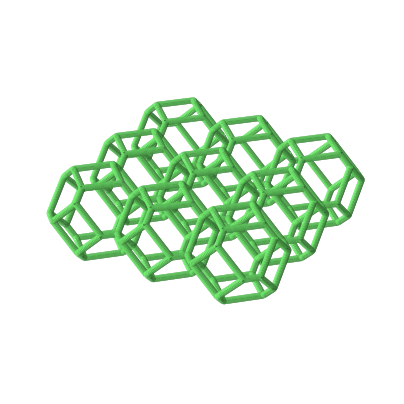

In [ ]:


####################################
# check readme
####################################
params = {'base': 2.,'height':5.,'phi':0.0,'delta':0.0, 'nx': 3, 'ny':3, 'nz':1,
            'Name':'C4','Shape':'Square'}

scale = 25.4 # inch to mm 
H = 0.5*scale# 0.5 inch per row height

W = 1*scale  # 1 inch
B = 1*scale  # 1 inch

params['height'] =  H
params['base'] =  H

params['Name']='C12'
p = 7

mf = MeshFrame()

nodeXY,connectivity,radiiElemIndex = mf.generateCombined3DLattice(params)
# radiiNodIndex,radiiElemIndex help to map radii of one unit cell to multiple unit cell
numUnitLatElem = max(radiiElemIndex) + 1        
#calculate the total length of the beam elements
lengthElem = np.linalg.norm(nodeXY[connectivity[:,0],:] - nodeXY[connectivity[:,1],:],axis=1)
totalLength = np.sum(lengthElem)
print("Total length of the beams in mm = ", totalLength)

E = torch.tensor([17.0])
elemSize = 0.8 #0.8

midpointsZ = (nodeXY[connectivity[:,0],-1] 
             + nodeXY[connectivity[:,1],-1]) / 2
midpointsZ = np.round(midpointsZ,decimals=3)
midpointsUnique = np.unique(midpointsZ)

alpha = []
if p == 2:
    alphaTop = (midpointsZ>max(nodeXY[:,-1])/2)*1.0 + (midpointsZ == max(nodeXY[:,-1])/2)*0.5
    alphaBot = (midpointsZ<max(nodeXY[:,-1])/2)*1.0 + (midpointsZ == max(nodeXY[:,-1])/2)*0.5
    alpha.append(alphaBot);
    alpha.append(alphaTop)
else:       
    if len(midpointsUnique) > p:
        listComb = [1,2,2,3,2,2,1] # group few of the beams together to apply same radius
        count = 0;
        for i in range(len(listComb)):
            if listComb[i] == 1:
                mat = 1.0*(midpointsZ == midpointsUnique[count]) 
                count +=1
            elif listComb[i] == 2:
                mat1 = 1.0*(midpointsZ == midpointsUnique[count]) 
                mat2 = 1.0*(midpointsZ == midpointsUnique[count+1])
                mat = mat1 + mat2
                count +=2
            elif listComb[i] == 3:
                mat1 = 1.0*(midpointsZ == midpointsUnique[count]) 
                mat2 = 1.0*(midpointsZ == midpointsUnique[count+1])
                mat3 = 1.0*(midpointsZ == midpointsUnique[count+2])
                mat = mat1 + mat2 + mat3
                count += 3 
            alpha.append(mat)
    else:
        for i in range(len(midpointsUnique)):
            alpha.append(1.0*(midpointsZ == midpointsUnique[i]))
        
alpha = np.stack(alpha,axis=0)
r0 = np.ones(p)*0.5 # 0.5 radius in mm
# r0 = np.array([0.7,0.7])
R = np.einsum('ij,i->j',alpha,r0)

cleanImage = True

fig_set = plt.figure(figsize=(10,10))
result = plotStructure(R,nodeXY,connectivity,str(p)+' unique radius ',plotDeformed = False,TrueScale=True,fig=fig_set,
    thicknessPlot=True,elemAnnotate=False,nodeAnnotate=False)

# Handle return value: could be ax alone or (ax, cbar)
if isinstance(result, tuple):
    ax, cbar = result
    cbar.remove()
else:
    ax = result
# keep z limit first
ax.set_zlim(0, H)
# get current x,y limits (may require a draw if axes auto-updates)
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
z0, z1 = ax.get_zlim()

xspan = abs(x1 - x0)
yspan = abs(y1 - y0)
zspan = abs(z1 - z0)

# set relative box aspect so physical scale is equal
ax.set_box_aspect((xspan, yspan, zspan))
# fig_set.savefig('Images/New/StructureC4_axes.png', bbox_inches='tight', pad_inches=0, dpi=300,transparent=True)

if cleanImage:
    # remove everything in the background from ax, just plot, no axes, no ticks, no labels, no spines, no title, no bars
    ax.set_axis_off()
    ax.set_title('')
    # fig_set.savefig('Images/New/StructureC4.png', bbox_inches='tight', pad_inches=0, dpi=300,transparent=True)


In [11]:

inputCurve = (np.array([0.0000000000000000, 0.6350000000000000, 1.2700000000000000,
1.9050000000000000, 2.5400000000000000, 3.1749999999999998,
3.8099999999999996, 4.4449999999999994, 5.0799999999999992,
5.7149999999999990, 6.3499999999999988])/1.25, 
8.0*np.array([0.0000000000000000, 1,1,1,1,1,1,1,1,1,1])) # 

max_x = 1.0
min_x = 0.2
ObjType = "FD"   
        
varSetup = {'min_x':min_x,'max_x':max_x}
path = params['Name']+'NN'+str(p)+'var/' # to save the results and data

# # Represent the current curve as a function of normalized displacement
# ui = torch.linspace(inputCurve[0].min(), inputCurve[0].max(), steps=100, dtype=torch.float64)
# t = (ui - ui.min()) / (ui.max() - ui.min())
# Fi = 5 * (ui)**(1/2.5)
# optFrame = OptimizeFrame(None,inputCurve)
# fig = optFrame.plot_fd_curves(
#             ui,
#             Fi,
#             label_tag="Current FD Curve",
#             target_only=False,
#             fig=plt.figure(figsize=(8, 6)),
#             normalize=False,
#             save_dir='Images/New/Target_Current_FD.png',
#             )


In [12]:

seedNum = 0
if p==2:
    dataType = params['Name']+'uniform_2var_seedNum0'
else:
    dataType = params['Name']+'LHS_'+str(p)+'var_seedNum'+str(seedNum)
    
dataSavePath = 'DataVar/'+dataType+'.txt'
if not os.path.exists(dataSavePath):
    dataGen(p,2500,dataSavePath,seedNum)
else:
    print("Data file already exists, skipping data generation")


Data file already exists, skipping data generation


In [8]:

print("##########################################")
abaqusResultsPath = path +'abaqusComp40'+dataType +'_0_2500.txt'
print(abaqusResultsPath)
# Run abaqus analysis to get data 
if not os.path.exists(abaqusResultsPath):
    print("Run abaqus on the data file:",dataSavePath)
    print(f"Abaqus file {abaqusResultsPath} does not exists")
    sys.exit()
else:
    print("Abaqus analysis file already exists, continuing to check surrogate model")


##########################################
C4NN7var/abaqusComp40C4LHS_7var_seedNum0_0_2500.txt
Abaqus analysis file already exists, continuing to check surrogate model


In [14]:
    
print("##########################################")
# Build NN surrogate
surrogateModelLoc = path + 'SurrogateModel.pth'
if not os.path.exists(surrogateModelLoc):
    print("Surrogate model does not exist, run the surrogate model training using SurrogateBuild.ipynb")
    sys.exit()
else:
    print("Surrogate model already exists, using it")


##########################################
Surrogate model already exists, using it


##########################################
Running optimization usign the NN surrogate start....
Target Curve =  (array([0.                , 0.508             , 1.016             , 1.524             , 2.032             , 2.54              , 3.0479999999999996, 3.5559999999999996, 4.063999999999999 , 4.571999999999999 , 5.079999999999999 ]), array([0., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.]))
seed number for optimization =  2
x0 = [0.43599490214200376  0.025926231827891333 0.5496624778787091   0.4353223926182769   0.42036780208748903  0.3303348210038741   0.2046486340378425  ], for start point = 1
Normalized wrt =  [2.0250290462676195]
Running MMA optimizer from mmapy
Iter 1: f0 = 0.8497, L-best = 0.8507, KKT norm = 1.204, Function evals = 2, n = 7


<Figure size 432x288 with 0 Axes>

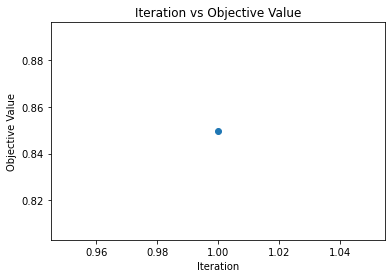

Iter 2: f0 = 0.8494, L-best = 0.8504, KKT norm = 1.319, Function evals = 3, n = 7


/home/akshayk/Documents/GitHub/LatticeFDOpt/src/optimizeFrame3.py:243: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


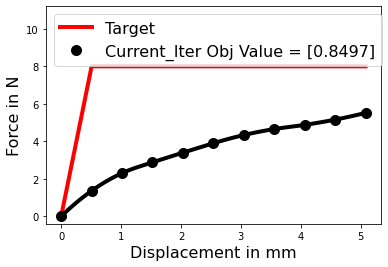

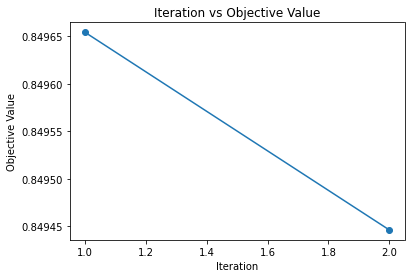

Iter 3: f0 = 0.6369, L-best = 0.6379, KKT norm = 1.464, Function evals = 4, n = 7


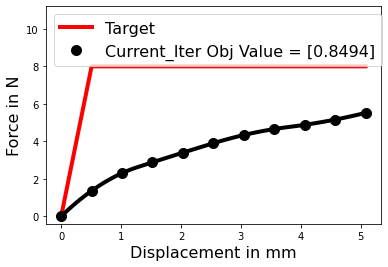

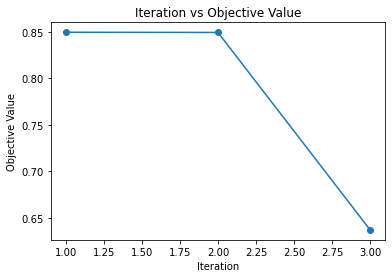

Iter 4: f0 = 0.5028, L-best = 0.5038, KKT norm = 5.66, Function evals = 6, n = 7


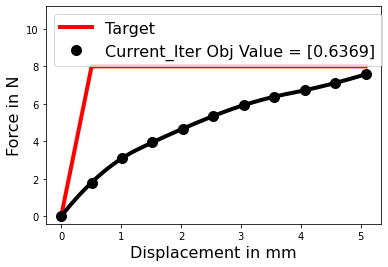

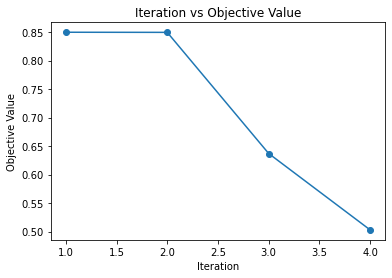

Iter 5: f0 = 0.5028, L-best = 0.5038, KKT norm = 1.789, Function evals = 17, n = 7


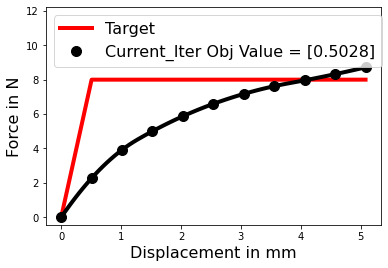

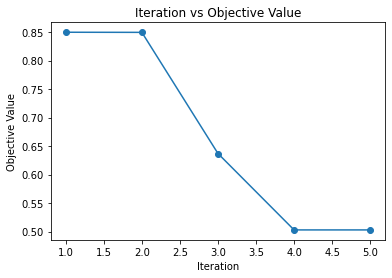

Iter 6: f0 = 0.396, L-best = 0.397, KKT norm = 4.786, Function evals = 20, n = 7


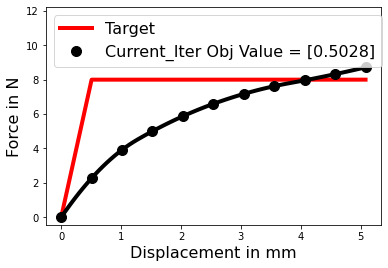

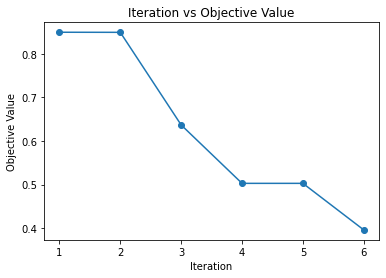

Iter 7: f0 = 0.3927, L-best = 0.3937, KKT norm = 2.108, Function evals = 28, n = 7


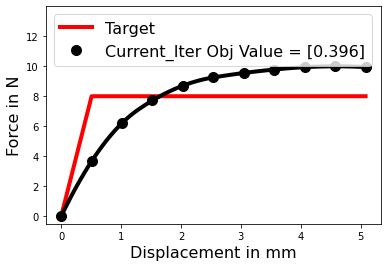

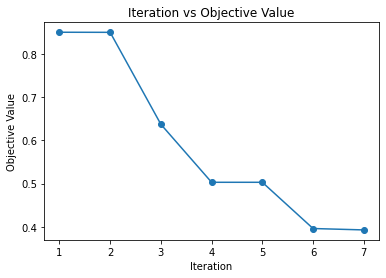

Iter 8: f0 = 0.3927, L-best = 0.3937, KKT norm = 2.108, Function evals = 39, n = 7


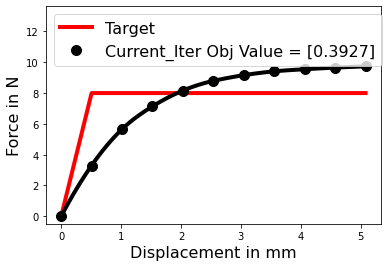

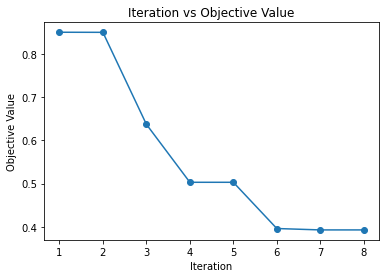

Iter 9: f0 = 0.3801, L-best = 0.3811, KKT norm = 0.7675, Function evals = 45, n = 7


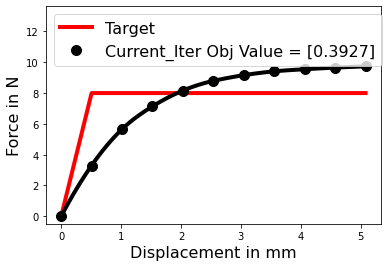

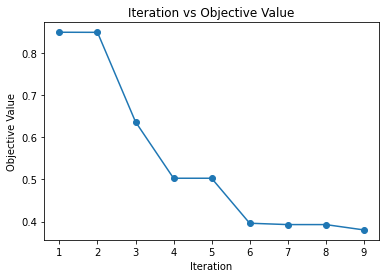

Iter 10: f0 = 0.3795, L-best = 0.3805, KKT norm = 0.4244, Function evals = 51, n = 7


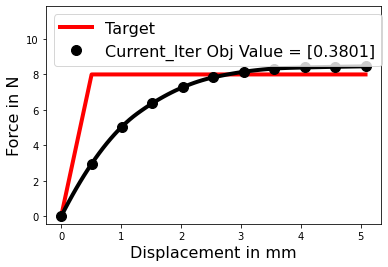

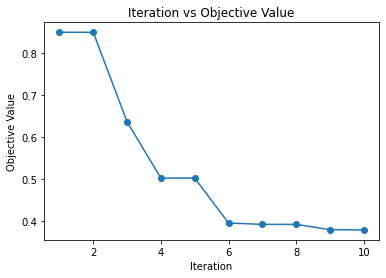

Iter 11: f0 = 0.3795, L-best = 0.3805, KKT norm = 0.4244, Function evals = 62, n = 7


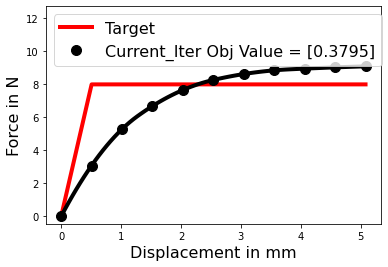

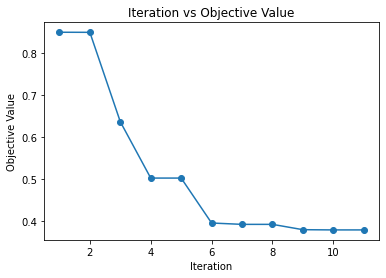

Iter 12: f0 = 0.3795, L-best = 0.3805, KKT norm = 0.4244, Function evals = 73, n = 7


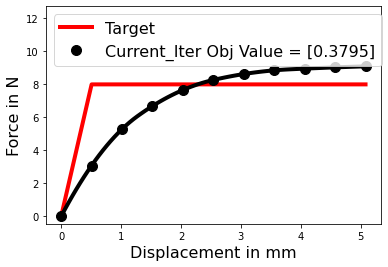

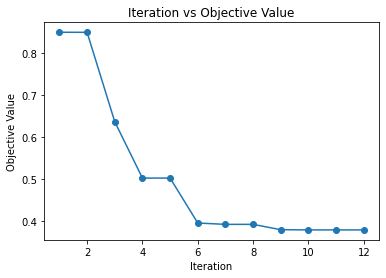

Iter 13: f0 = 0.3795, L-best = 0.3805, KKT norm = 0.4244, Function evals = 84, n = 7


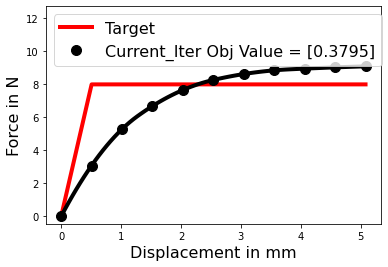

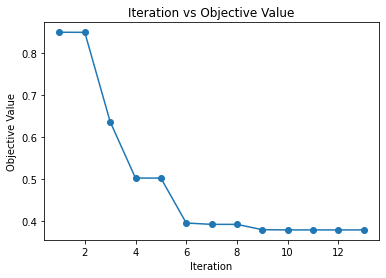

Local minima found
Solution =  tensor([0.80677826698199361921, 0.49572772560696859445, 0.46275792486882633137, 0.48818653601673578368, 0.47913859622284499240, 0.45790654943790037867, 0.41117902091381136609])
Opt Obj/Obj0 =  tensor([0.37953185823772622731])
Opt Obj =  tensor([0.76856303691532013023])


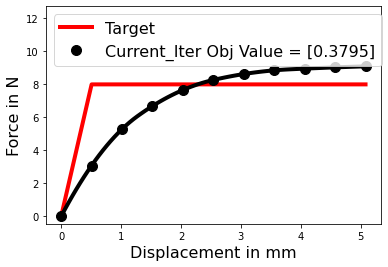

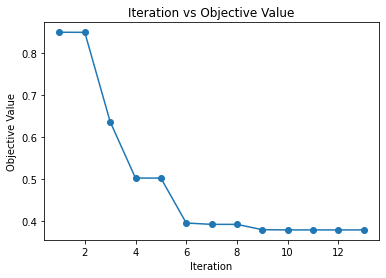

Opt x =  [0.8067782669819936  0.4957277256069686  0.46275792486882633 0.4881865360167358  0.479138596222845   0.4579065494379004  0.41117902091381137]
##################################################
x0 = [0.6192709663506637  0.29965467367452314 0.26682727510286663 0.6211338327692949  0.5291420942770391  0.13457994534493356 0.5135781212657464 ], for start point = 2
Normalized wrt =  [2.873407851301986]
Running MMA optimizer from mmapy
Iter 1: f0 = 0.6357, L-best = 0.6367, KKT norm = 1.353, Function evals = 2, n = 7


<Figure size 432x288 with 0 Axes>

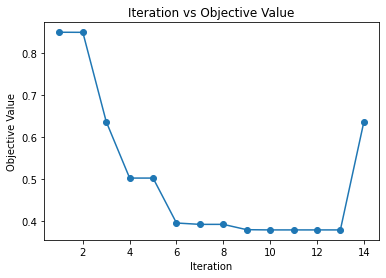

Iter 2: f0 = 0.6355, L-best = 0.6365, KKT norm = 1.574, Function evals = 3, n = 7


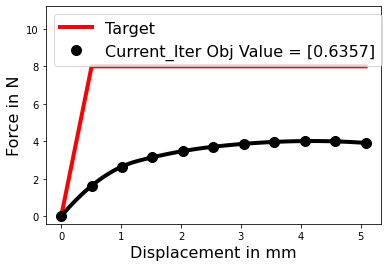

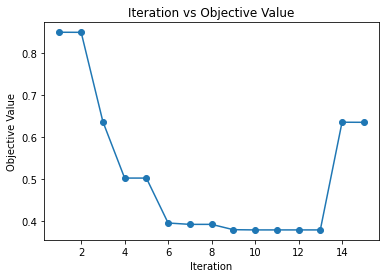

Iter 3: f0 = 0.4387, L-best = 0.4397, KKT norm = 1.452, Function evals = 4, n = 7


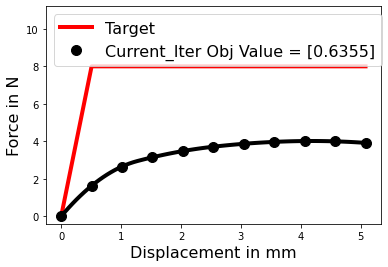

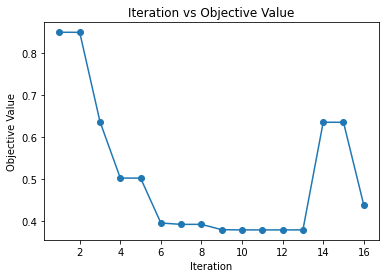

Iter 4: f0 = 0.4387, L-best = 0.4397, KKT norm = 1.621, Function evals = 15, n = 7


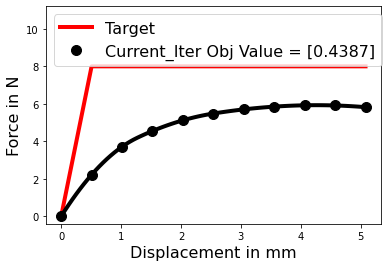

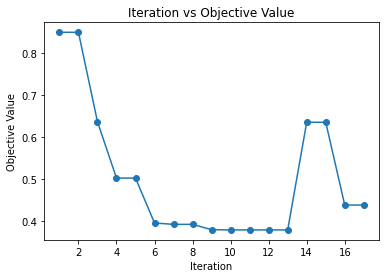

Iter 5: f0 = 0.2898, L-best = 0.2908, KKT norm = 1.657, Function evals = 17, n = 7


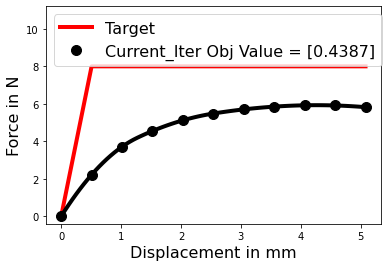

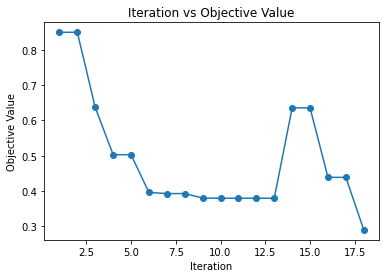

Iter 6: f0 = 0.2898, L-best = 0.2908, KKT norm = 0.9368, Function evals = 28, n = 7


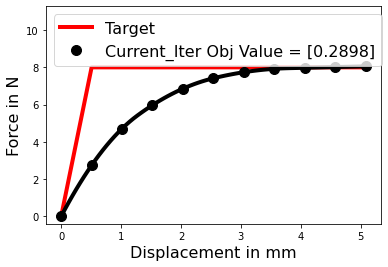

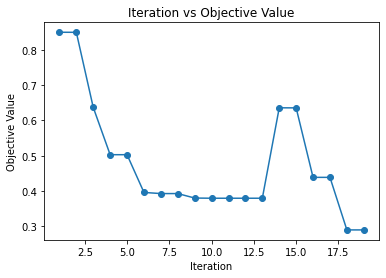

Iter 7: f0 = 0.2898, L-best = 0.2908, KKT norm = 0.9368, Function evals = 39, n = 7


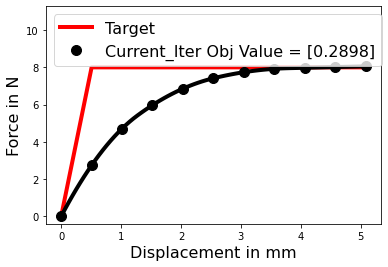

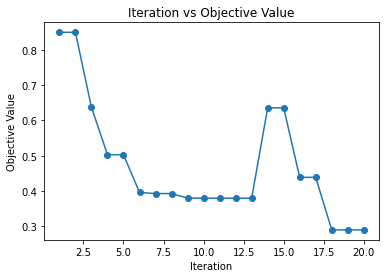

Iter 8: f0 = 0.2726, L-best = 0.2736, KKT norm = 0.7547, Function evals = 41, n = 7


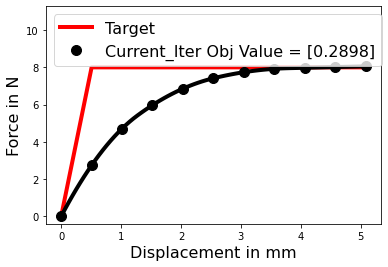

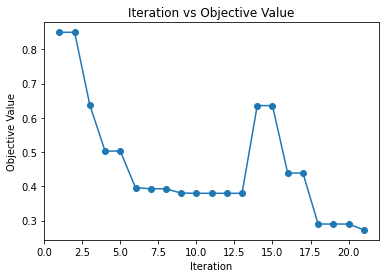

Iter 9: f0 = 0.2726, L-best = 0.2736, KKT norm = 0.6625, Function evals = 52, n = 7


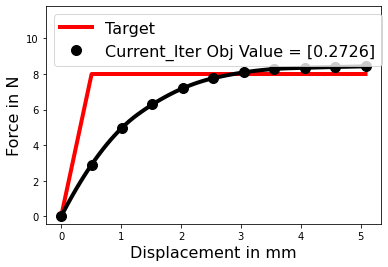

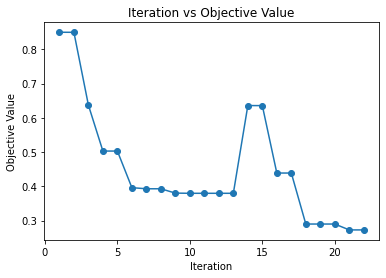

Iter 10: f0 = 0.2726, L-best = 0.2736, KKT norm = 0.6625, Function evals = 63, n = 7


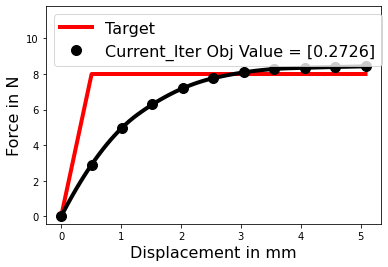

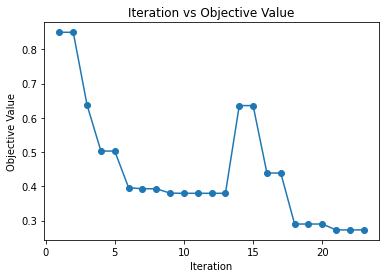

Iter 11: f0 = 0.2726, L-best = 0.2736, KKT norm = 0.6625, Function evals = 74, n = 7


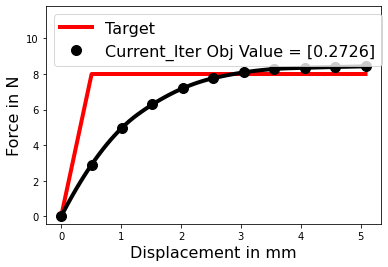

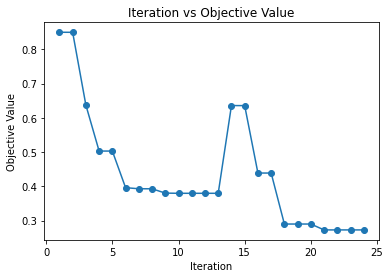

Local minima found
Solution =  tensor([0.89605023938548722384, 0.49845524210235120366, 0.47922246518530664527, 0.43249590865230408410, 0.46275036618200671157, 0.41582192427445791028, 0.36531342531078137004])
Opt Obj/Obj0 =  tensor([0.27263575102248865933])
Opt Obj =  tensor([0.78339370753363235522])


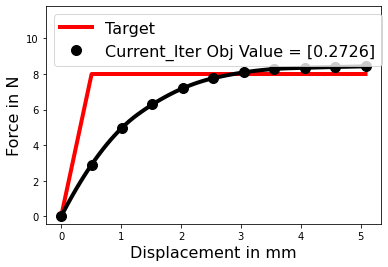

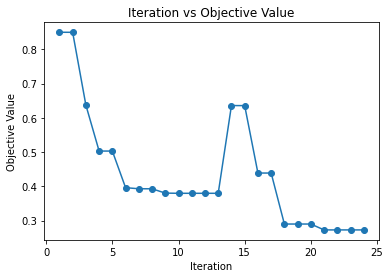

Opt x =  [0.8960502393854872  0.4984552421023512  0.47922246518530665 0.4324959086523041  0.4627503661820067  0.4158219242744579  0.36531342531078137]
##################################################
x0 = [0.18443986564691528 0.7853351478166735  0.8539752926394888  0.4942368373819278  0.846561485357468   0.079645477009061   0.505246090121704  ], for start point = 3
Normalized wrt =  [2.479488502637319]
Running MMA optimizer from mmapy
Iter 1: f0 = 0.497, L-best = 0.498, KKT norm = 2.666, Function evals = 2, n = 7


<Figure size 432x288 with 0 Axes>

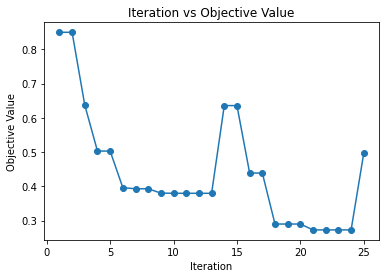

Iter 2: f0 = 0.4968, L-best = 0.4978, KKT norm = 1.259, Function evals = 3, n = 7


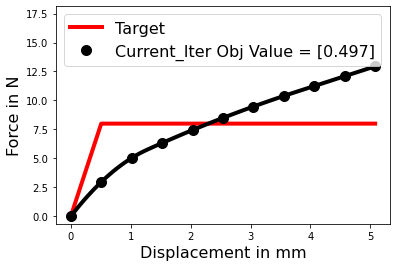

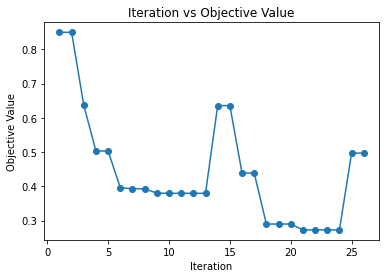

Iter 3: f0 = 0.4186, L-best = 0.4196, KKT norm = 1.756, Function evals = 4, n = 7


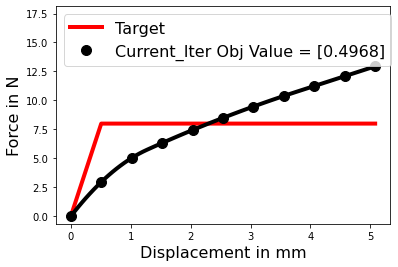

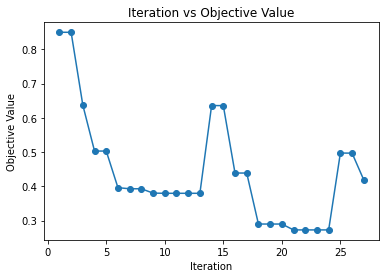

Iter 4: f0 = 0.3576, L-best = 0.3586, KKT norm = 1.067, Function evals = 5, n = 7


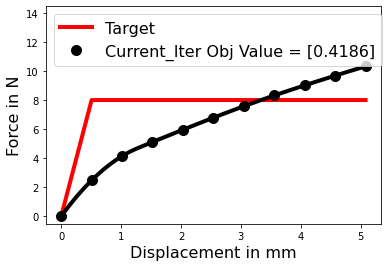

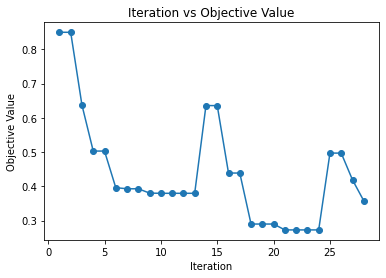

Iter 5: f0 = 0.3576, L-best = 0.3586, KKT norm = 1.042, Function evals = 16, n = 7


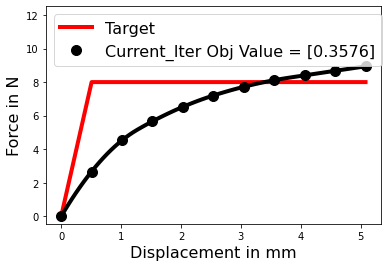

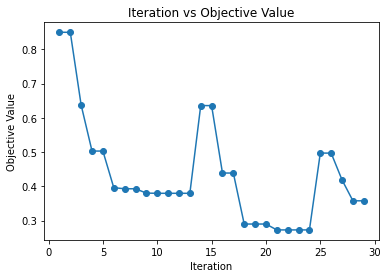

Iter 6: f0 = 0.3398, L-best = 0.3408, KKT norm = 2.562, Function evals = 19, n = 7


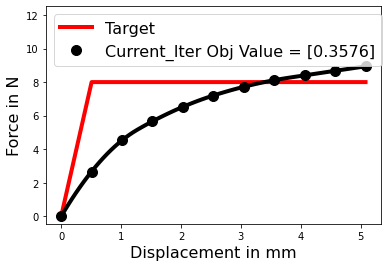

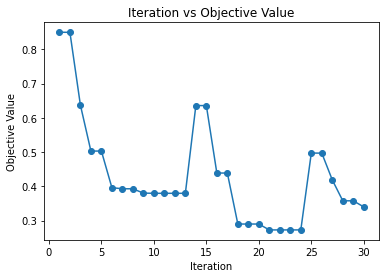

Iter 7: f0 = 0.3398, L-best = 0.3408, KKT norm = 2.561, Function evals = 30, n = 7


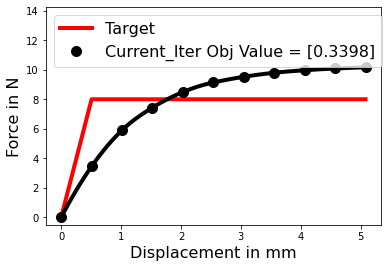

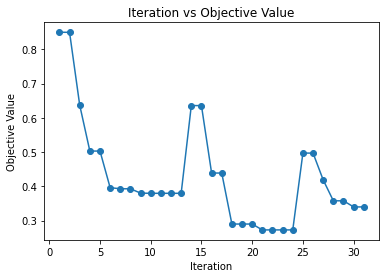

Iter 8: f0 = 0.3352, L-best = 0.3362, KKT norm = 1.007, Function evals = 36, n = 7


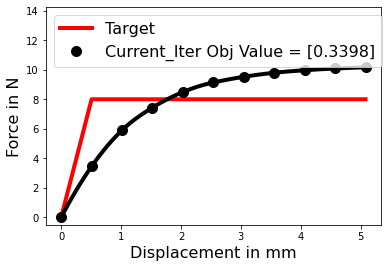

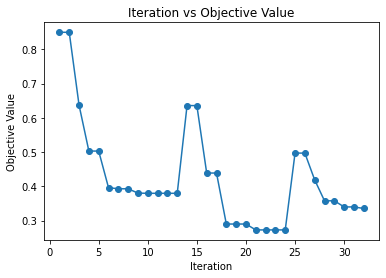

Iter 9: f0 = 0.3135, L-best = 0.3145, KKT norm = 0.1062, Function evals = 42, n = 7


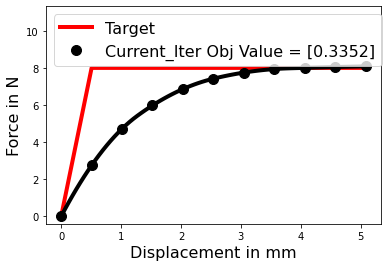

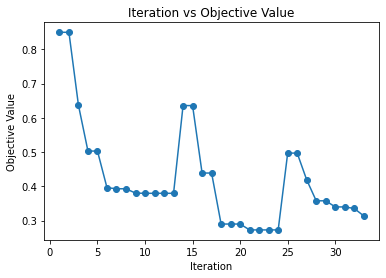

Iter 10: f0 = 0.2844, L-best = 0.2854, KKT norm = 2.463, Function evals = 43, n = 7


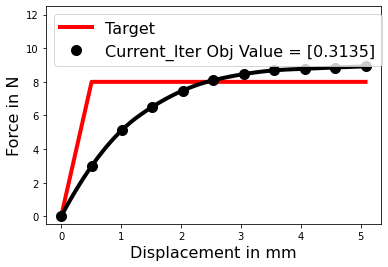

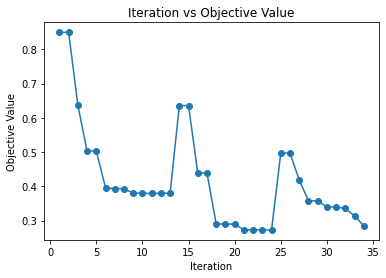

Iter 11: f0 = 0.2844, L-best = 0.2854, KKT norm = 2.463, Function evals = 54, n = 7


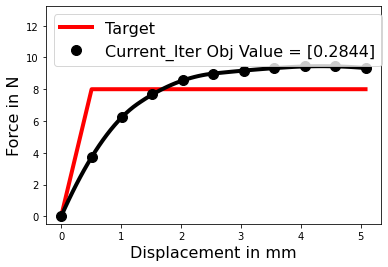

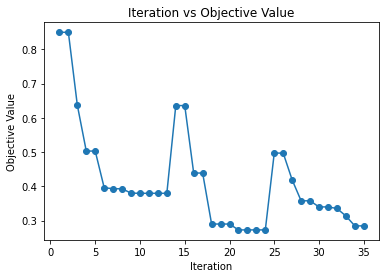

Iter 12: f0 = 0.2844, L-best = 0.2854, KKT norm = 2.463, Function evals = 65, n = 7


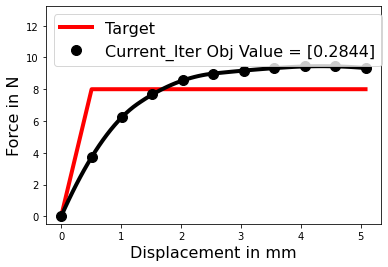

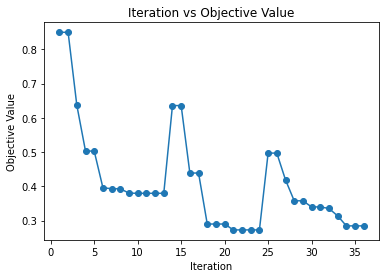

Iter 13: f0 = 0.2844, L-best = 0.2854, KKT norm = 2.463, Function evals = 76, n = 7


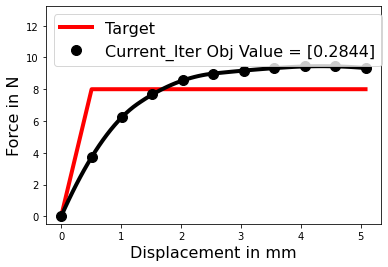

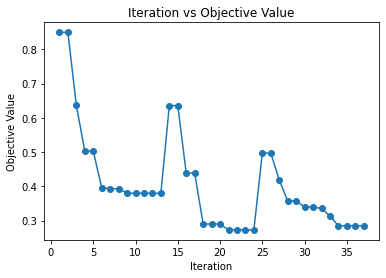

Local minima found
Solution =  tensor([0.57430759400637509948, 0.66046395049472150784, 0.58188983851599151986, 0.42336642088892001423, 0.43115461827333884104, 0.53473076166000210740, 0.43415030511768665233])
Opt Obj/Obj0 =  tensor([0.28441144314404465110])
Opt Obj =  tensor([0.70519490329414624696])


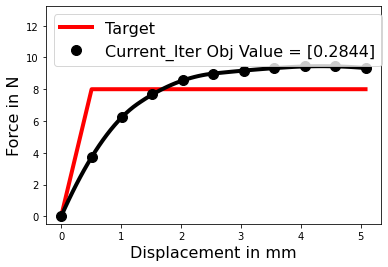

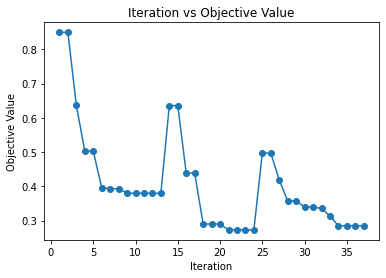

Opt x =  [0.5743075940063751  0.6604639504947215  0.5818898385159915  0.42336642088892    0.43115461827333884 0.5347307616600021  0.43415030511768665]
##################################################
x0 = [0.06528650438687811 0.42812232759738944 0.09653091566061256 0.12715997170127746 0.5967453089785958  0.22601200060423587 0.10694568430998297], for start point = 4
Normalized wrt =  [3.8732615010538862]
Running MMA optimizer from mmapy
Iter 1: f0 = 0.6657, L-best = 0.6667, KKT norm = 0.5211, Function evals = 2, n = 7


<Figure size 432x288 with 0 Axes>

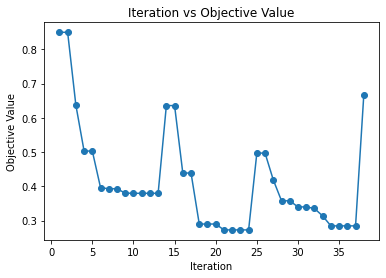

Iter 2: f0 = 0.6657, L-best = 0.6667, KKT norm = 0.6271, Function evals = 3, n = 7


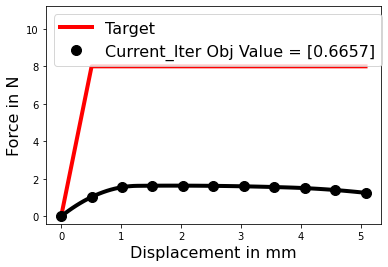

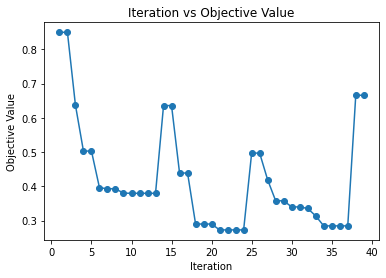

Iter 3: f0 = 0.5945, L-best = 0.5955, KKT norm = 0.9033, Function evals = 4, n = 7


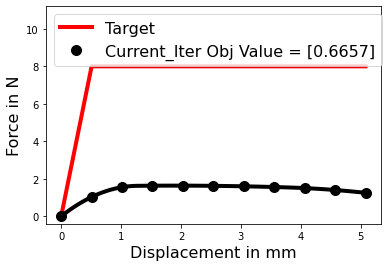

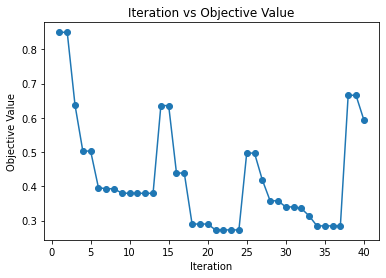

Iter 4: f0 = 0.1892, L-best = 0.1902, KKT norm = 1.856, Function evals = 5, n = 7


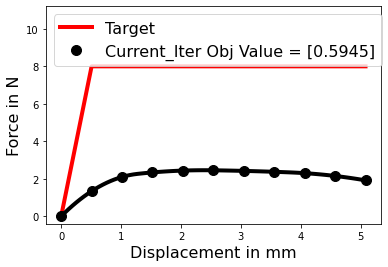

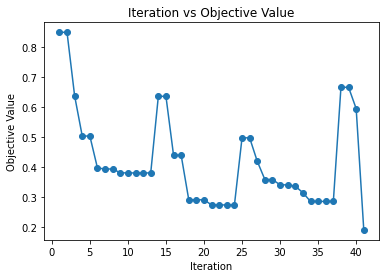

Iter 5: f0 = 0.1892, L-best = 0.1902, KKT norm = 1.578, Function evals = 16, n = 7


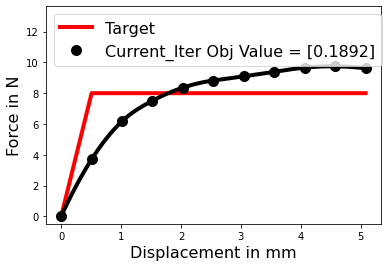

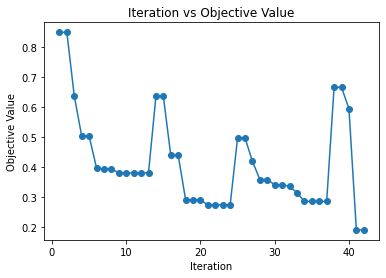

Iter 6: f0 = 0.1892, L-best = 0.1902, KKT norm = 1.578, Function evals = 27, n = 7


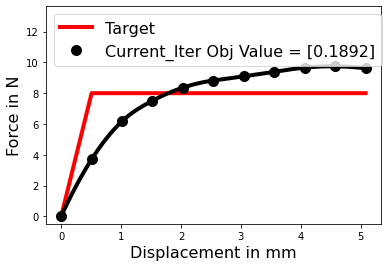

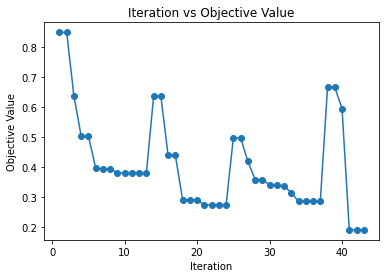

Iter 7: f0 = 0.1892, L-best = 0.1902, KKT norm = 1.578, Function evals = 38, n = 7


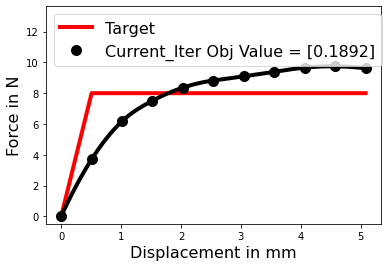

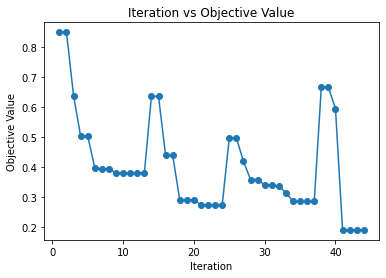

Iter 8: f0 = 0.1892, L-best = 0.1902, KKT norm = 1.578, Function evals = 49, n = 7


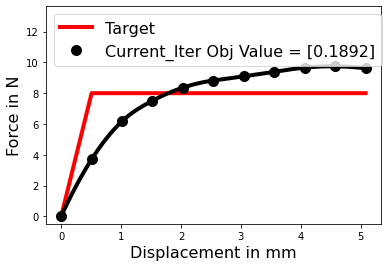

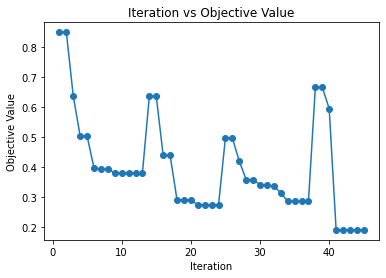

Iter 9: f0 = 0.1892, L-best = 0.1902, KKT norm = 1.578, Function evals = 60, n = 7


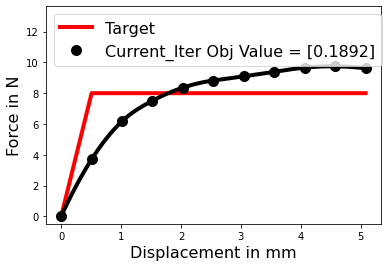

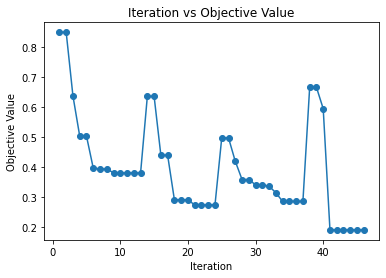

Local minima found
Objective did not change for last 4 iterations
Solution =  tensor([0.03166166945682572648, 0.52748891942294662272, 0.39175856916456747170, 0.30813388582385670134, 0.89196740214178316108, 0.52123342729020849529, 0.34101364406879519642])
Opt Obj/Obj0 =  tensor([0.18918491093600925401])
Opt Obj =  tensor([0.73276263210875303145])


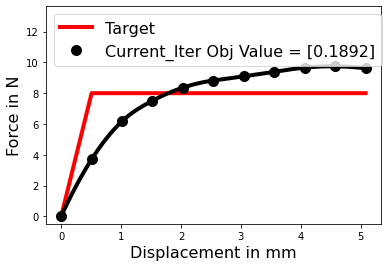

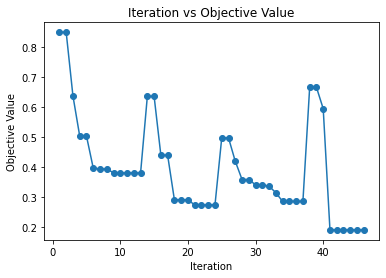

Opt x =  [0.031661669456825726 0.5274889194229466   0.39175856916456747  0.3081338858238567   0.8919674021417832   0.5212334272902085   0.3410136440687952  ]
##################################################
x0 = [0.2203062070705597  0.34982628500329926 0.46778748458230024 0.20174322626496533 0.6404067252149148  0.48306983555175165 0.5052367200185491 ], for start point = 5
Normalized wrt =  [1.1299031952728456]
Running MMA optimizer from mmapy
Iter 1: f0 = 0.7328, L-best = 0.7338, KKT norm = 0.9805, Function evals = 12, n = 7


<Figure size 432x288 with 0 Axes>

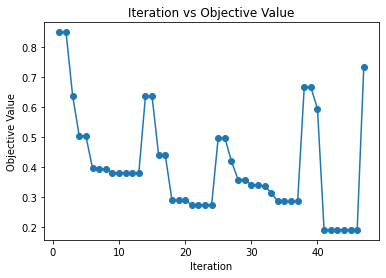

Iter 2: f0 = 0.7326, L-best = 0.7336, KKT norm = 1.086, Function evals = 13, n = 7


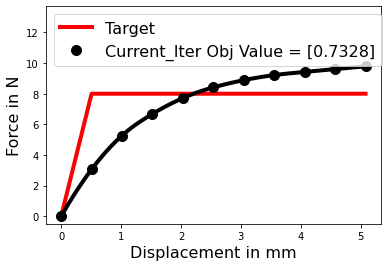

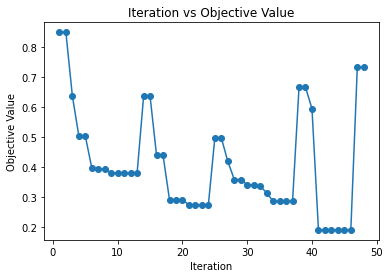

Iter 3: f0 = 0.7305, L-best = 0.7315, KKT norm = 6.685, Function evals = 15, n = 7


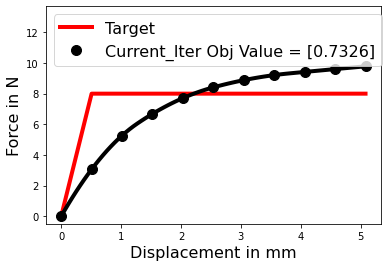

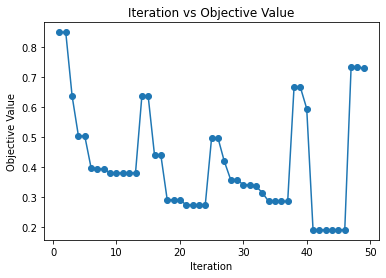

Iter 4: f0 = 0.7305, L-best = 0.7315, KKT norm = 1.2, Function evals = 26, n = 7


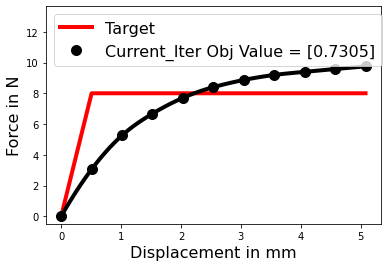

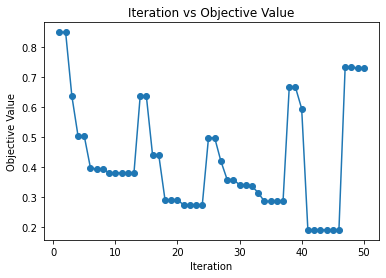

Iter 5: f0 = 0.7298, L-best = 0.7308, KKT norm = 2.016, Function evals = 28, n = 7


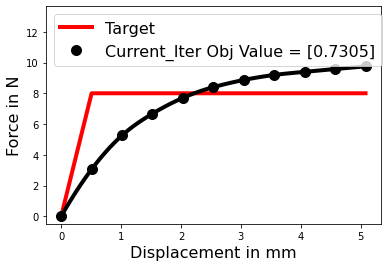

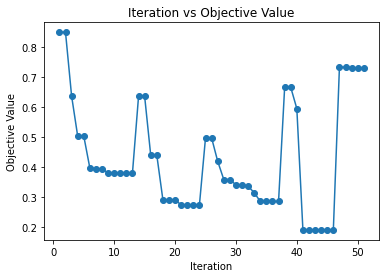

Iter 6: f0 = 0.7298, L-best = 0.7308, KKT norm = 3.298, Function evals = 39, n = 7


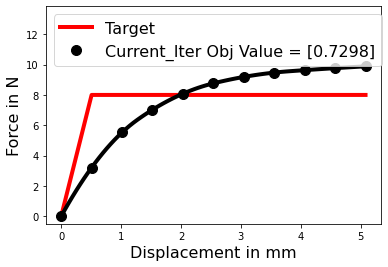

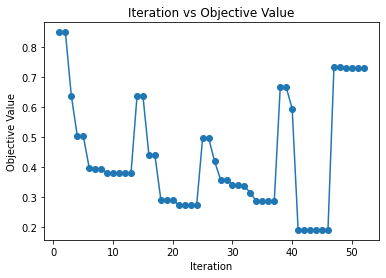

Iter 7: f0 = 0.7298, L-best = 0.7308, KKT norm = 3.298, Function evals = 50, n = 7


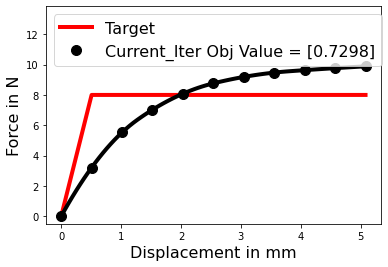

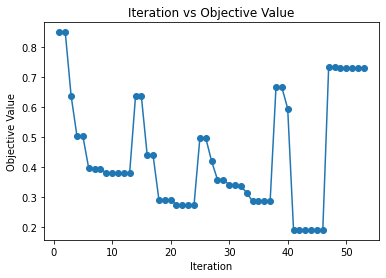

Iter 8: f0 = 0.7298, L-best = 0.7308, KKT norm = 3.298, Function evals = 61, n = 7


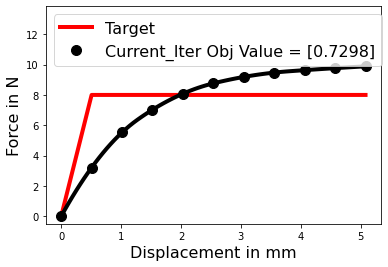

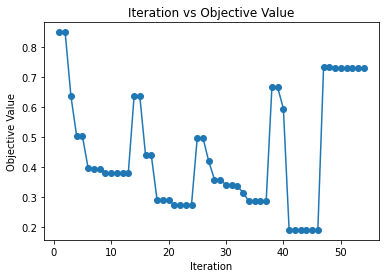

Iter 9: f0 = 0.7172, L-best = 0.7182, KKT norm = 4.402, Function evals = 69, n = 7


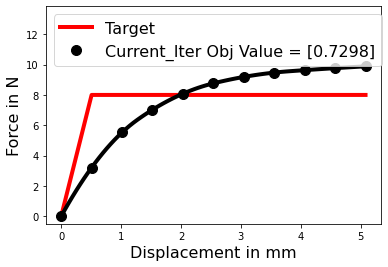

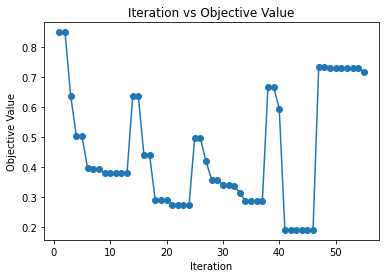

Iter 10: f0 = 0.7172, L-best = 0.7182, KKT norm = 2.396, Function evals = 80, n = 7


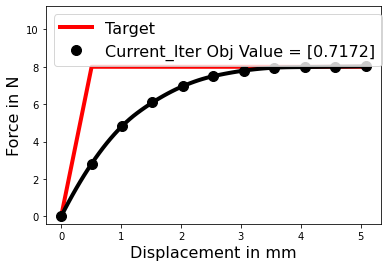

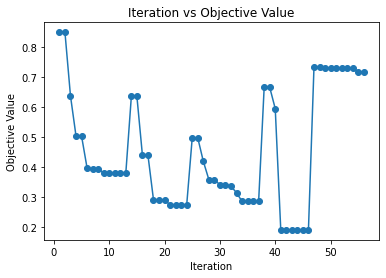

Iter 11: f0 = 0.7172, L-best = 0.7182, KKT norm = 2.396, Function evals = 91, n = 7


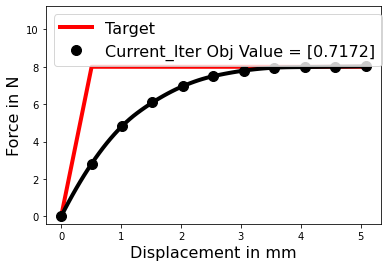

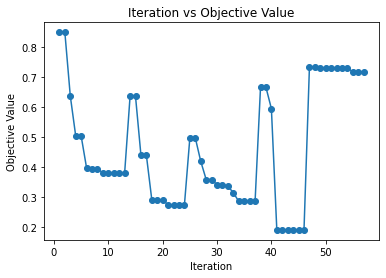

Iter 12: f0 = 0.7119, L-best = 0.7129, KKT norm = 2.659, Function evals = 96, n = 7


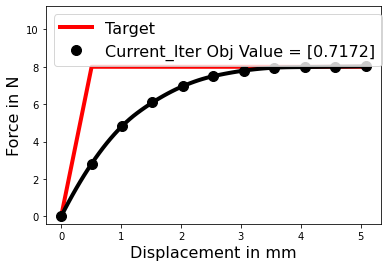

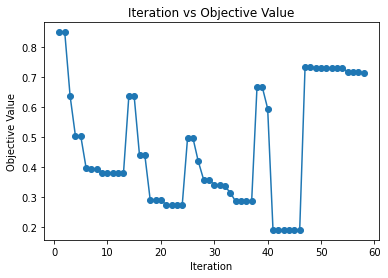

Iter 13: f0 = 0.7119, L-best = 0.7129, KKT norm = 2.659, Function evals = 107, n = 7


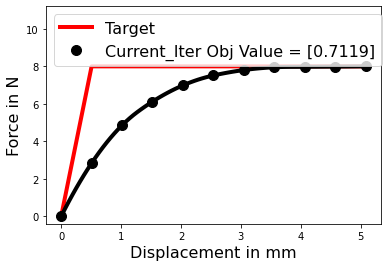

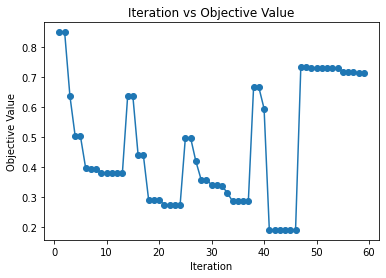

Iter 14: f0 = 0.7119, L-best = 0.7129, KKT norm = 2.659, Function evals = 118, n = 7


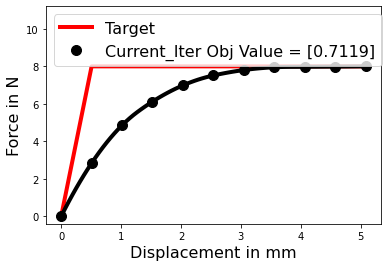

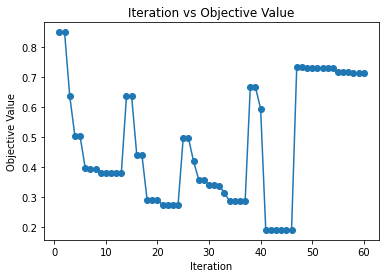

Iter 15: f0 = 0.6824, L-best = 0.6834, KKT norm = 2.252, Function evals = 120, n = 7


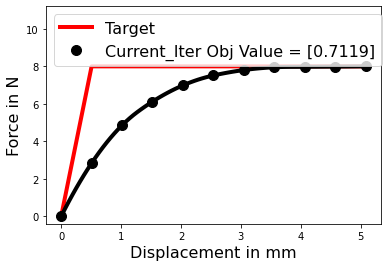

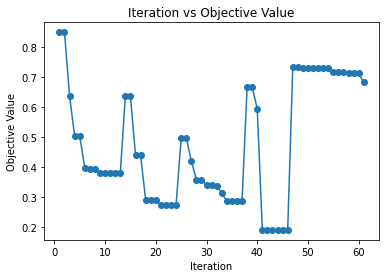

Iter 16: f0 = 0.6824, L-best = 0.6834, KKT norm = 0.7729, Function evals = 131, n = 7


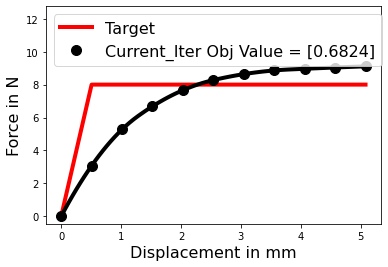

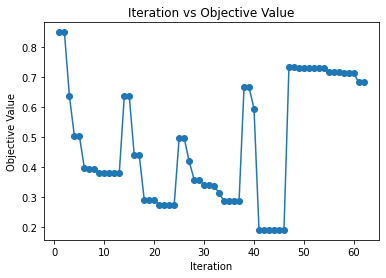

Iter 17: f0 = 0.6824, L-best = 0.6834, KKT norm = 0.7729, Function evals = 142, n = 7


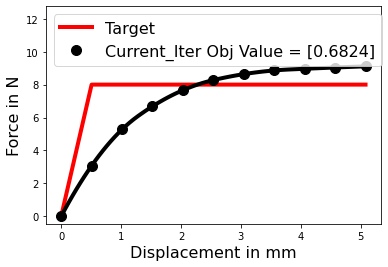

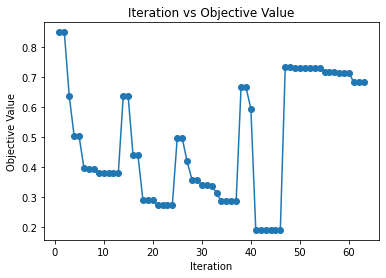

Iter 18: f0 = 0.6817, L-best = 0.6827, KKT norm = 2.289, Function evals = 144, n = 7


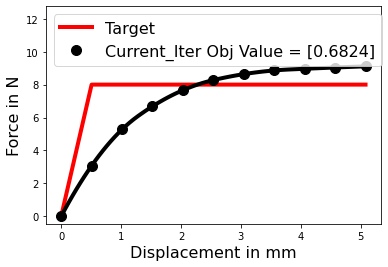

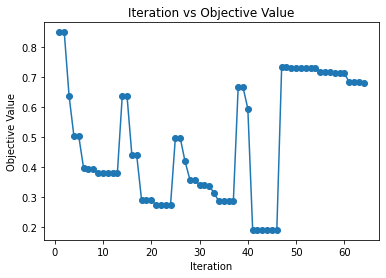

Iter 19: f0 = 0.6817, L-best = 0.6827, KKT norm = 0.2454, Function evals = 155, n = 7


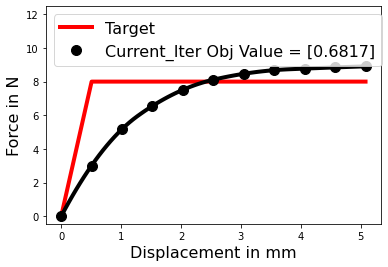

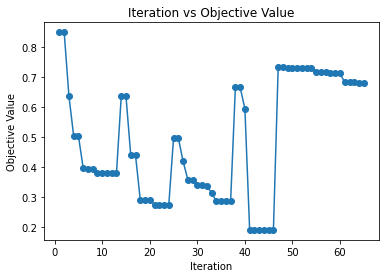

Iter 20: f0 = 0.6817, L-best = 0.6827, KKT norm = 0.1628, Function evals = 166, n = 7


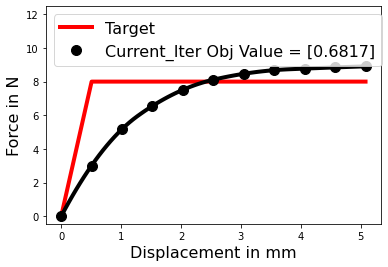

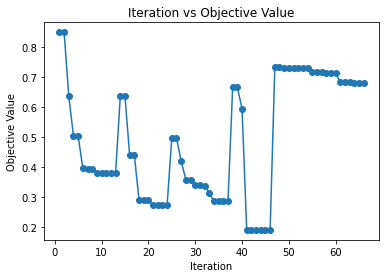

Iter 21: f0 = 0.6817, L-best = 0.6827, KKT norm = 7.902, Function evals = 168, n = 7


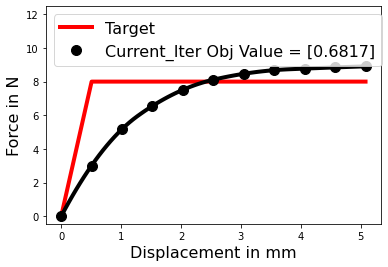

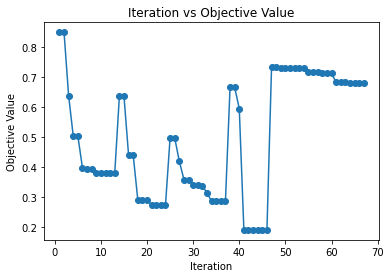

Iter 22: f0 = 0.6816, L-best = 0.6826, KKT norm = 0.1292, Function evals = 169, n = 7


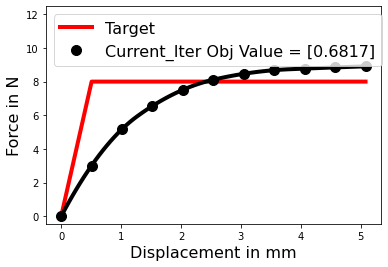

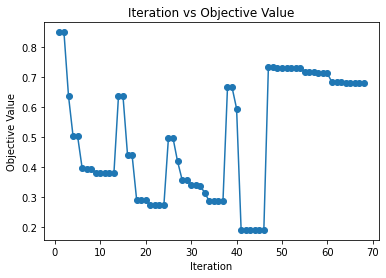

Iter 23: f0 = 0.6399, L-best = 0.6409, KKT norm = 0.6609, Function evals = 170, n = 7


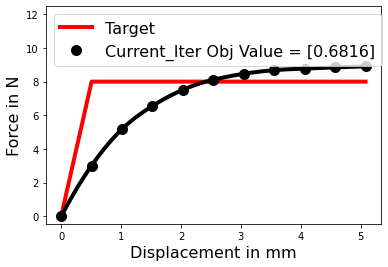

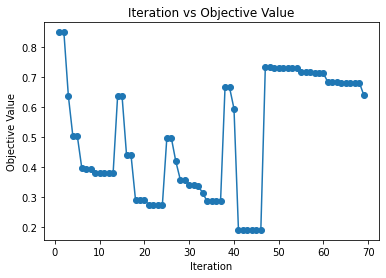

Iter 24: f0 = 0.5376, L-best = 0.5386, KKT norm = 8.436, Function evals = 173, n = 7


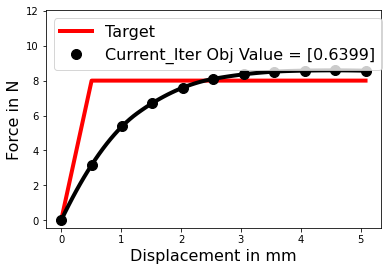

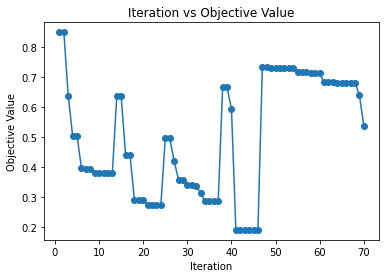

Iter 25: f0 = 0.5376, L-best = 0.5386, KKT norm = 2.383, Function evals = 184, n = 7


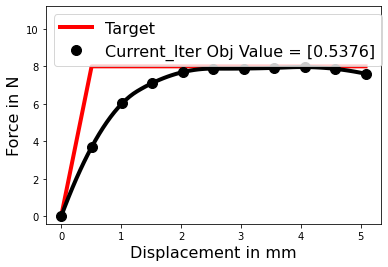

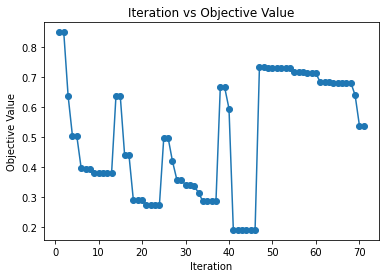

Iter 26: f0 = 0.5376, L-best = 0.5386, KKT norm = 2.664, Function evals = 195, n = 7


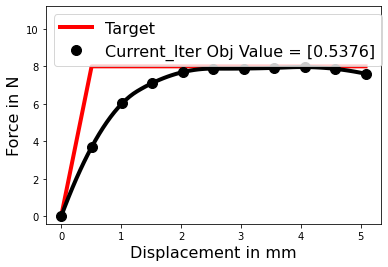

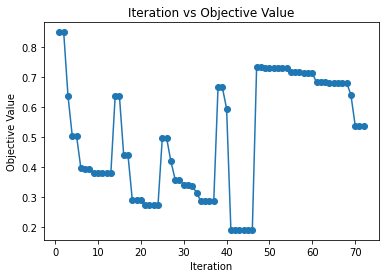

Iter 27: f0 = 0.5376, L-best = 0.5386, KKT norm = 2.664, Function evals = 206, n = 7


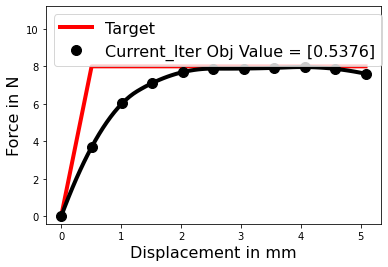

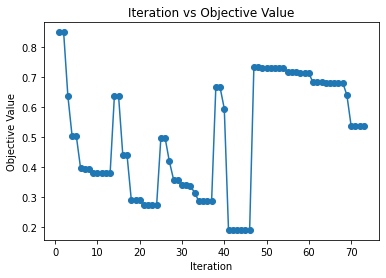

Iter 28: f0 = 0.5134, L-best = 0.5144, KKT norm = 2.302, Function evals = 213, n = 7


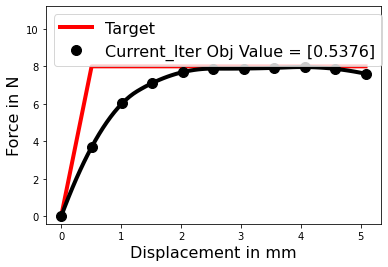

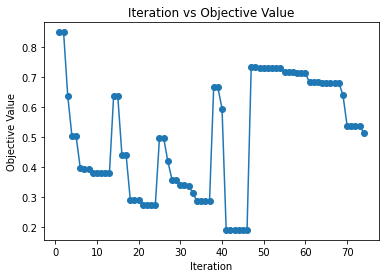

Iter 29: f0 = 0.5134, L-best = 0.5144, KKT norm = 2.302, Function evals = 224, n = 7


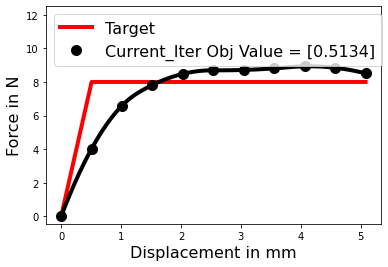

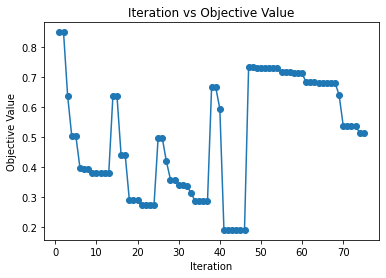

Iter 30: f0 = 0.5134, L-best = 0.5144, KKT norm = 2.302, Function evals = 235, n = 7


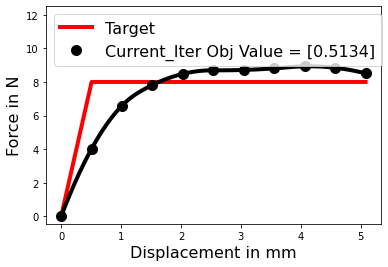

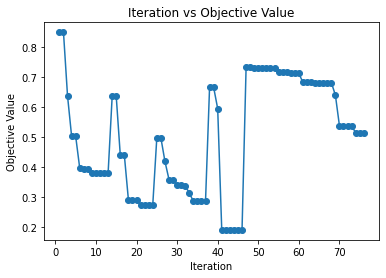

Iter 31: f0 = 0.5134, L-best = 0.5144, KKT norm = 2.302, Function evals = 246, n = 7


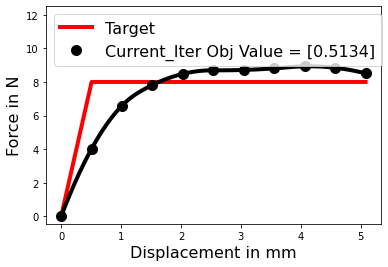

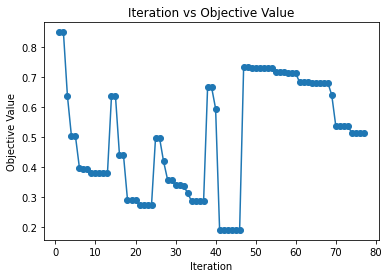

Local minima found
Solution =  tensor([0.35169819259175905124, 0.84054082319141987245, 0.28568221216901507065, 0.75176957202138749992, 0.68081659932551974457, 0.75897014382146976708, 0.57468354738184557196])
Opt Obj/Obj0 =  tensor([0.51343884712915877078])
Opt Obj =  tensor([0.58013619394844262445])


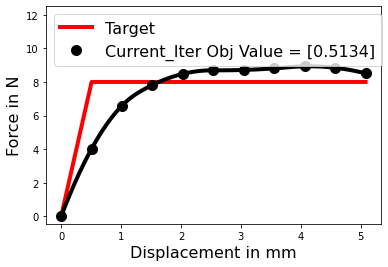

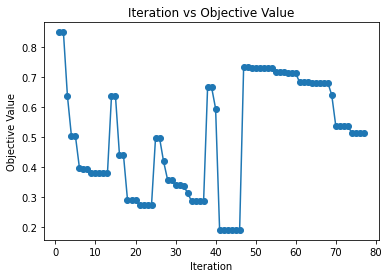

Opt x =  [0.35169819259175905 0.8405408231914199  0.28568221216901507 0.7517695720213875  0.6808165993255197  0.7589701438214698  0.5746835473818456 ]
##################################################
Time for optimization in sec =  122.8694907410536
##########################################
Initial guesses and optimization results saved to file: DataVar/C4solution_7var_seedNum0.txt
 Run abaqus on these DataVar/C4solution_7var_seedNum0.txt for validation


<Figure size 432x288 with 0 Axes>

In [15]:

print("##########################################")
print("Running optimization usign the NN surrogate start....")
print("Target Curve = ",inputCurve)

########################################################
frameNN = torch.load(surrogateModelLoc)# switch device to cpu if needed,map_location=torch.device('cpu')) # Load to device
frameNN.eval()  # Set to evaluation mode
optFrame = OptimizeFrame(frameNN,inputCurve)
inputdim = optFrame.frameNN.nnSettings['inputDim']

fileSavePath = path+'NNmultiStart' # to save the figures of optimization run
# Check if the savePath exists
if not os.path.exists(fileSavePath):
    # Create the directory
    os.makedirs(fileSavePath)
    
st = time.perf_counter()
Algo = 'MMA'# 'L-BFGS-B', 'SLSQP','TNC'
seedOptNum = 2 #2 for C4, and 3 for C12 
np.random.seed(seedOptNum)
print("seed number for optimization = ", seedOptNum)
x0_all = np.random.rand(5,inputdim)
xopt_all = np.zeros_like(x0_all)
for i in range(x0_all.shape[0]):
    print(f"x0 = {x0_all[i,:]}, for start point = {i+1}")
    x,fun=optFrame.optimizerRun(x0_all[i,:],algorithm=Algo,tol=1e-10,fileSaveLoc=fileSavePath)
    print("Opt x = ",x)
    xopt_all[i,:] = x
    print("##################################################")
    
Total_opt_time = time.perf_counter()-st
print("Time for optimization in sec = ", Total_opt_time)   
print("##########################################")

###################
output_filename = 'DataVar/'+params['Name']+'solution_'+str(p)+'var_seedNum0.txt'

with open(output_filename, 'w') as f:
    f.write(f"# Seed: {0}, Variables: {p}, Samples: {10}\n")
    f.write(f"# Each row represents a sample in the format [val1 ... valp]\n")

    # Write the samples data row by row in the desired format
    for sample_row in np.concatenate((x0_all,xopt_all),axis=0):
        # Format each float value to a specific number of decimal places and join with a space
        # Then wrap the entire string in square brackets
        formatted_row = " ".join([f"{val:.16f}" for val in sample_row]) # Using .16f for high precision
        f.write(f"[{formatted_row}]\n")
print("Initial guesses and optimization results saved to file:",output_filename)
print(f" Run abaqus on these {output_filename} for validation")
###################

In [ ]:
pause_savefig = True

print("##########################################")
solutionfilename = path + 'abaqusComp40'+params['Name']+'solution_'+str(p)+'var_seedNum0.txt'
if not os.path.exists(solutionfilename):
    print("Run abaqus on result file:",output_filename)
    sys.exit()
else:    
    print(f"Abaqus analysis file {solutionfilename} already exists, using it. Delete this if its an older file")
    #### read the abaqus solution curves
    R, U, F, analysisState = extract_ABQ_values(solutionfilename,torch.from_numpy(inputCurve[0]).reshape(-1)) # for abaqus code results
    DataAbaqusOpt = np.stack((U[5::,:],F[5::,:]),axis=2)
    analysisState = analysisState[5::]
            
    V0   = np.zeros_like(x0_all[:,0])
    Vopt = np.zeros_like(x0_all[:,0])
        
    V0, Vopt,VDataAbaqusOpt = plot_optimization_curves(optFrame, x0_all, xopt_all, V0, Vopt, DataAbaqusOpt)
    if pause_savefig:
        plt.savefig(path+'/Opt'+str(inputdim)+'var.png', bbox_inches='tight') # 'tight' removes extra whitespace
    
    print("########")
    print("x0_all,xopt_all = ",x0_all,xopt_all)
    print("V0,Vopt,VDataAbaqusOpt  = ",V0,Vopt,VDataAbaqusOpt)
    print("########")
    
    VDataAbaqusOpt[analysisState==0.0] = 0.0
    barPlotofOptimization(V0,Vopt,VDataAbaqusOpt)
    if pause_savefig:
        plt.savefig(path+'/BarOpt'+str(inputdim)+'var.png', bbox_inches='tight') # 'tight' removes extra whitespace
    
    if inputdim==2:
        xGlobalNN,ax =plot_objective_landscape(optFrame, 50)
    
        ax = plotOptxk(ax,optFrame,x0_all,"Initial Guesses ",'red','o',markersize=100)
        ax = plotOptxk(ax,optFrame,xopt_all,"Optimized Results ",'aqua' ,'^',markersize=100)
        
        ax = plotOptxk(ax,optFrame,xGlobalNN,"Gridsearch Minima ",'lime' ,'h',markersize=200)
        
        ax.legend(loc='lower right',fontsize=16,bbox_to_anchor=(0.95,0.05))
        if pause_savefig:
            plt.savefig(path+'/ObjSpaceNNFullData.png', bbox_inches='tight') # 'tight' removes extra whitespace
